## Part 1: Weighting Function Derivations

Given the extinction coefficient $\beta_e = C \exp(-z/H)$ , where $C$ is a constant, $z$ is height, and $H$ is the scale height.

**1. Optical Depth $\tau(z)$ and Total Optical Depth $\tau^*$** 
Integrating from a height $z$ to the top of the atmosphere (TOA, $z=\infty$):
$$\tau(z) = \int_z^\infty \beta_e(z') dz' = \int_z^\infty C \exp(-z'/H) dz' = C H \exp(-z/H)$$
The total optical depth of the atmosphere is evaluated from the surface ($z=0$):
$$\tau^* = \tau(0) = C H$$

**2. Flux Transmittance $t_F(z, \infty)$** 
Using the diffusivity parameter $r = 5/3$, the flux transmittance to space is:
$$t_F(z, \infty) = \exp(-r \tau(z)) = \exp \left( -r C H \exp(-z/H) \right)$$

**3. Upwelling Weighting Function $W_F^\uparrow(z)$** 
The weighting function is the derivative of the transmittance with respect to height $z$:
$$W_F^\uparrow(z) = \frac{d t_F(z, \infty)}{dz} = \exp(-r \tau(z)) \cdot \left( -r \frac{d\tau}{dz} \right)$$
Since $\frac{d\tau}{dz} = -\beta_e(z) = -C \exp(-z/H)$:
$$W_F^\uparrow(z) = r C \exp(-z/H) \exp \left( -r C H \exp(-z/H) \right)$$

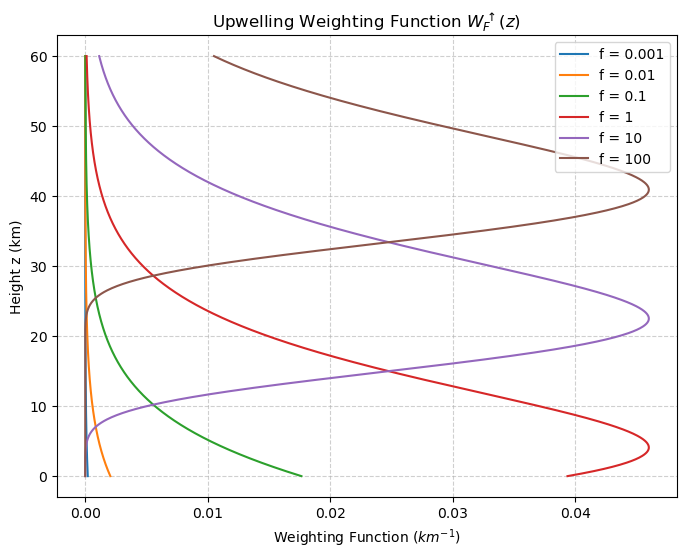

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# --- Constants & Parameters ---
H = 8000.0          # Atmospheric scale height in meters (assumed standard)
r = 5/3             # Diffusivity parameter 
f_values_discrete = [0.001, 0.01, 0.1, 1, 10, 100]  # Scaling parameters 

# Height array from 0 to 60 km (60000 m) for high resolution
z = np.linspace(0, 60000, 1000)

def calc_C(f):
    """Calculates extinction constant C for a given f"""
    return f * 1.25e-4 

def weighting_function(z, f):
    """Calculates the upwelling weighting function W_F(z)"""
    C = calc_C(f)
    tau_z = C * H * np.exp(-z / H)
    W = r * C * np.exp(-z / H) * np.exp(-r * tau_z)
    return W

# --- Plot Part 1: Weighting Functions ---
plt.figure(figsize=(8, 6))

for f in f_values_discrete:
    W_z = weighting_function(z, f)
    plt.plot(W_z * 1000, z / 1000, label=f'f = {f}') # Scaled for readability, z in km

plt.title(r'Upwelling Weighting Function $W_F^\uparrow(z)$ ')
plt.xlabel(r'Weighting Function ($km^{-1}$)')
plt.ylabel('Height z (km)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**5. Changes in $W_F^\uparrow(z)$ and outgoing LW Radiation**

The upwelling weighting function describes the height in the atmosphere where there is the greatest contribution of radiation to the top of the atmosphere. Greater values of f, representing increasing gas concentration, correspond to weighting functions which peak at greater heights in the atmosphere. The more gas in the atmosphere, the more longwave radiation from the surface is absorbed and retransmitted. With denser gas, most surface transmission is absorbed, so the peak of most unobstructed longwave radiation is higher, because at high altitude, there is less gas absorbing below the ToA. 

Thus, changing the longwave upwelling weighting function by changing the gas concentration, proportionally affects the outgoing longwave radiation at the ToA, as higher concentrations absorb more longwave radiation, and lower concentrations absorb less.

## Part 2: TOA Outgoing LW Radiation

**1. Monochromatic Upwelling Flux at TOA** 
The flux to space combines the surface emission transmitted to TOA and the atmospheric emission:
$$F_\lambda^\uparrow(\infty) = \pi B_\lambda(T_{surf}) t_F(0, \infty) + \int_0^\infty \pi B_\lambda(T(z)) W_F^\uparrow(z) dz$$
*(Note: $\pi B_\lambda$ is used for flux, where $B_\lambda$ is the Planck function).*

**2. Monochromatic Net Flux at TOA** 
Net flux is $F_n = F^\uparrow - F^\downarrow$. Since there is no downwelling longwave radiation from space at the TOA ($F^\downarrow(\infty) = 0$), the net flux equals the upwelling flux:
$$F_{n, \lambda}(\infty) = F_\lambda^\uparrow(\infty)$$

**Direct Radiative Forcing**
$$\Delta F = F_{n, \lambda}(\infty; f) - F_{n, \lambda}(\infty; f=0)$$

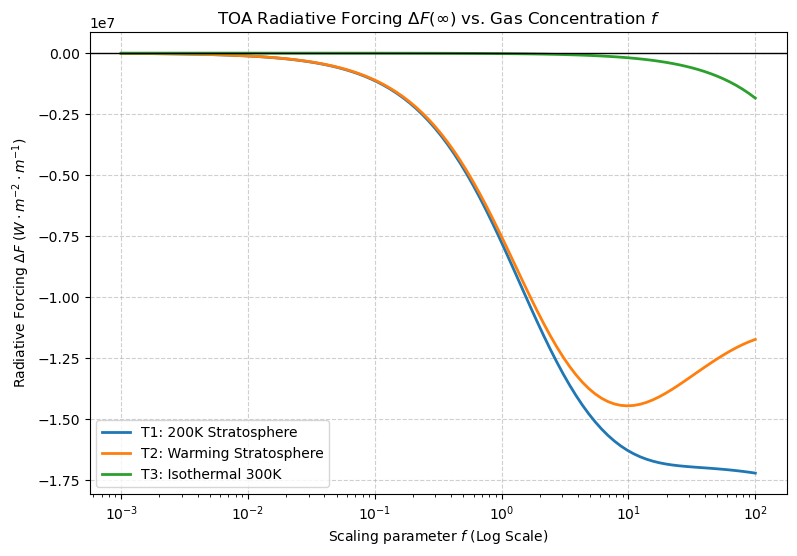

In [10]:
# --- Additional Parameters for Part 2 ---
lam = 15e-6          # Wavelength in meters (15 um) 
h_planck = 6.626e-34 # Planck constant (J s)
c_light = 3.0e8      # Speed of light (m/s)
k_boltz = 1.38e-23   # Boltzmann constant (J/K)
T_surf = 300.0       # Surface temperature (K) 

# Continuous f values for smoother plots 
f_continuous = np.logspace(-3, 2, 100)

def planck_flux(T, wavelength):
    """Calculates monochromatic flux (pi * B_lambda) emitted by a blackbody."""
    if np.any(T <= 0): return np.zeros_like(T)
    B_lambda = (2 * h_planck * c_light**2) / (wavelength**5) * \
               (1 / (np.exp((h_planck * c_light) / (wavelength * k_boltz * T)) - 1))
    return np.pi * B_lambda

def t_F_surface(f):
    """Calculates surface flux transmittance to TOA."""
    C = calc_C(f)
    tau_star = C * H
    return np.exp(-r * tau_star)

def net_flux_toa(z, T_profile, f):
    """Calculates net outgoing monochromatic flux at TOA"""
    # Surface contribution
    F_surf = planck_flux(T_surf, lam) * t_F_surface(f)
    
    # Atmospheric contribution (integral)
    W = weighting_function(z, f)
    B_atmos = planck_flux(T_profile, lam)
    # Integrate using Simpson's rule over the z-domain
    F_atmos = simpson(B_atmos * W, z)
    
    return F_surf + F_atmos

# --- Define Temperature Profiles ---
# T1: Standard lapse rate to 20km, then isothermal 200K
T1 = np.where(z <= 20000, 300 - 0.005 * z, 200)

# T2: Stratospheric warming. 
# Assuming continuous profile from 20km (200K) to 50km (260K) -> Gamma_s = 2 K/km
Gamma_s = 0.002 # 2 K/km -> K/m
T2 = np.piecewise(z, 
                  [z <= 20000, (z > 20000) & (z <= 50000), z > 50000],
                  [lambda z: 300 - 0.005 * z, 
                   lambda z: 200 + Gamma_s * (z - 20000), 
                   260])

# T3: Isothermal atmosphere 
T3 = np.full_like(z, 300.0)

# --- Calculate Radiative Forcing ---
# Baseline fluxes (f=0 implies C=0, completely transparent atmosphere)
F_net_0_T1 = net_flux_toa(z, T1, 0.0)
F_net_0_T2 = net_flux_toa(z, T2, 0.0)
F_net_0_T3 = net_flux_toa(z, T3, 0.0)

delta_F_T1 = []
delta_F_T2 = []
delta_F_T3 = []

for f in f_continuous:
    # Profile 1 forcing 
    delta_F_T1.append(net_flux_toa(z, T1, f) - F_net_0_T1)
    # Profile 2 forcing 
    delta_F_T2.append(net_flux_toa(z, T2, f) - F_net_0_T2)
    # Profile 3 forcing 
    delta_F_T3.append(net_flux_toa(z, T3, f) - F_net_0_T3)

# --- Plot Part 2: Radiative Forcing ---
plt.figure(figsize=(9, 6))

plt.plot(f_continuous, delta_F_T1, label='T1: 200K Stratosphere', lw=2)
plt.plot(f_continuous, delta_F_T2, label='T2: Warming Stratosphere', lw=2)
plt.plot(f_continuous, delta_F_T3, label='T3: Isothermal 300K', lw=2)

plt.xscale('log')
plt.title(r'TOA Radiative Forcing $\Delta F(\infty)$ vs. Gas Concentration $f$')
plt.xlabel('Scaling parameter $f$ (Log Scale)')
plt.ylabel(r'Radiative Forcing $\Delta F$ ($W \cdot m^{-2} \cdot m^{-1}$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', lw=1)
plt.show()

+ **Shape of $\Delta F(\infty)$ in terms of changes in $W_F^\uparrow(z)$ and $T1(z)$**

In T1, the temperature profile goes from 300K at the surface to 200K past 20km. As we increase f, and thus the height of the peak of the weighting function $W_F^\uparrow(z)$, the direct radative forcing decreases, which is to say that the difference between the flux at the surface and the flux at the ToA increases. We see this sharp decline in the plot because lower temperatures emit less longwave radiation, which drives that difference in flux from the surface to the ToA. Increasing the concentration of gas further exacerbates this difference in flux as it increasingly absorbs longwave radiation from the surface, and the peak of the weighting function is at higher and colder levels of the atmosphere.

+ **Shape of $\Delta F(\infty)$ in terms of changes in $W_F^\uparrow(z)$ and $T2(z)$**

In T2, the temperature profile is a little more complex, starting still at 300K at the surface, decreasing to 200K at 20km, but then *rising* to 260K at 50km. This implies a stratospheric warming effect. We see this effect come into play when we look at larger concentrations of gas in the atmosphere. Referring to the figure, a similar profile for radiative forcing appears as for the simple temperature profile, until we dramatically increase the scaling parameter (the concentration of gas). This increase in $\Delta F(\infty)$, (which, again, is to say the *decrease* in flux differences,) happens due to the stratospheric warming. With stratospheric warming, the increase of gas concentration (past a critical point) actually decreases the flux difference between the surface and the ToA, because the peak of the weighting function would be moved upwards into the stratosphere, so that the bulk of longwave radiation will be coming from a warmer part of the atmosphere, thus emitting more in total, driving the flux difference back down. The minimum value of $\Delta F(\infty)$ corresponds with the concentration at which the weighting function peaks at the *coldest* part of the atmosphere, that is, the border region between the troposphere and the stratosphere. At this coldest region, the longwave radiation is emitted the least, so the difference between the flux at the relatively hot surface and the flux at this cold region is the greatest.

+ **Shape of $\Delta F(\infty)$ in terms of changes in $W_F^\uparrow(z)$ and $T3(z)$**

In T3, the temperature profile is constant, meaning that the temperature is 300K from the surface to the ToA. The isotropicity means that no matter where the weighting function peaks, it will always be from a part of the atmosphere that is at 300K. This is why the flux difference remains almost constant until very high concentrations of gas. At these concentrations, absorbance of longwave radiation from the atmosphere becomes significant enough to drive a difference in surface flux and ToA flux.


In [ ]:
import os

# Define the name of your subfolder
output_dir = "figures"

# Create the folder if it doesn't already exist in your current working directory
os.makedirs(output_dir, exist_ok=True)
print(f"Directory '{output_dir}' is ready!")